Khởi tạo môi trường, kết nối ChromaDB và nạp dữ liệu

In [ ]:
# Cài đặt thư viện (nếu chưa có chạy: !pip install chromadb pandas sentence-transformers)
import pandas as pd
import chromadb
import json
import time
from chromadb.utils import embedding_functions

# 1. Load Ground Truth
gt_df = pd.read_excel(r'G:\Khoa_Luan\Source_code\backend\chunking\IUH_Retrival_Chatbot_GroundTruth.xlsx')
print(f"Đã tải {len(gt_df)} câu hỏi kiểm thử.")

# 2. Load Web Structure Graph (để dùng cho Tree Search)
with open(r'G:\Khoa_Luan\Source_code\data\markdown_craw3\web_structure_graph.json', 'r', encoding='utf-8') as f:
    web_graph = json.load(f)
print(f"Đã tải sơ đồ website với {len(web_graph.key())} node.")

# 3. Kết nối ChromaDB và thiết lập Embedding Model

chroma_client = chromadb.PersistentClient(path=r"G:\Khoa_Luan\Source_code\data\chroma_db") 


emb_fn = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
) 

# Bước 3.3: Gọi Collection và truyền emb_fn vào để đồng bộ hóa
collection = chroma_client.get_collection(
    name="camnang_iuh_collection", 
    embedding_function=emb_fn
)

print("Khởi tạo môi trường thành công!")

Đã tải 28 câu hỏi kiểm thử.
Đã tải sơ đồ website với 134 node.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Khởi tạo môi trường thành công!


Xây dựng Baseline 1 - Vector RAG Thuần túy

In [2]:
def baseline_1_vector_rag(query, k=3):
    """Truy xuất dựa hoàn toàn vào Vector Similarity."""
    start_time = time.time()
    
    # Thực hiện query vào ChromaDB
    results = collection.query(
        query_texts=[query],
        n_results=k
    )
    
    latency = time.time() - start_time
    
    # Trích xuất metadata và URLs trả về
    retrieved_chunks = results['documents'][0]
    retrieved_metadata = results['metadatas'][0]
    retrieved_urls = [meta.get('source', '') for meta in retrieved_metadata]
    
    return {
        "method": "Vector Only",
        "retrieved_chunks": retrieved_chunks,
        "retrieved_urls": retrieved_urls,
        "latency": latency
    }

# Test thử Cell 2
test_q = gt_df.iloc[0]['Query']
print(f"Test Query: {test_q}")
res_b1 = baseline_1_vector_rag(test_q, k=3)
print(f"Độ trễ B1: {res_b1['latency']:.4f}s - Số URL tìm thấy: {len(res_b1['retrieved_urls'])}")

Test Query: Trường Đại học Công nghiệp TP.HCM có những giá trị cốt lõi nào?
Độ trễ B1: 0.2878s - Số URL tìm thấy: 3


In [4]:
!pip install cohere

   ---------------------------------------- 0.0/352.0 kB ? eta -:--:--
   --- ----------------------------------- 30.7/352.0 kB 660.6 kB/s eta 0:00:01
   ---------- ----------------------------- 92.2/352.0 kB 1.1 MB/s eta 0:00:01
   ---------------------- ----------------- 194.6/352.0 kB 1.5 MB/s eta 0:00:01
   ------------------------------- -------- 276.5/352.0 kB 1.4 MB/s eta 0:00:01
   ---------------------------------------- 352.0/352.0 kB 1.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/446.5 kB ? eta -:--:--
   -------- ------------------------------- 92.2/446.5 kB 1.7 MB/s eta 0:00:01
   ------------- -------------------------- 153.6/446.5 kB 1.8 MB/s eta 0:00:01
   --------------------- ------------------ 235.5/446.5 kB 1.8 MB/s eta 0:00:01
   ------------------------------ --------- 337.9/446.5 kB 1.9 MB/s eta 0:00:01
   ------------------------------------- -- 419.8/446.5 kB 1.9 MB/s eta 0:00:01
   ---------------------------------------- 446.5/446.5 kB 1


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from sentence_transformers import CrossEncoder

local_reranker = CrossEncoder('BAAI/bge-reranker-v2-m3')


Đang tải mô hình BGE Reranker...


config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

g:\Khoa_Luan\Source_code\backend\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\VanBao\.cache\huggingface\hub\models--BAAI--bge-reranker-v2-m3. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

Tải xong!


In [15]:
def local_rerank(query, documents, urls, top_n=3):
    """Sắp xếp lại các documents dựa trên điểm số của BGE Reranker Local."""
    if not documents:
        return [], []
        
    # Tạo danh sách các cặp [câu hỏi, tài liệu] để đưa vào mô hình chấm điểm
    pairs = [[query, doc] for doc in documents]
    
    # Chấm điểm mức độ liên quan
    scores = local_reranker.predict(pairs)
    
    # Ghép điểm số với chunk và url, sau đó sắp xếp theo thứ tự điểm giảm dần
    scored_docs = list(zip(scores, documents, urls))
    scored_docs.sort(key=lambda x: x[0], reverse=True)
    
    # Trích xuất Top N chunk và url tốt nhất
    top_chunks = [doc for score, doc, url in scored_docs[:top_n]]
    top_urls = [url for score, doc, url in scored_docs[:top_n]]
    
    return top_chunks, top_urls

Xây dựng LLM Router và Tree Search (Cho Baseline 2)

In [16]:
import ollama

# Tên model bạn đã pull về máy
MODEL_NAME = 'qwen2:7b' 

def llm_router(query):
    """Phân loại câu hỏi vào Tier 1, 2, 3, hoặc 4 sử dụng Ollama local."""
    prompt = f"""
    Bạn là một trợ lý phân loại câu hỏi. Hãy phân loại câu hỏi dưới đây vào 1 trong 4 mức độ (chỉ trả về một con số duy nhất là 1, 2, 3, hoặc 4).

    Định nghĩa:
    1: Tra cứu dữ kiện đơn lẻ.
    2: Suy luận đa phần (so sánh, điều kiện).
    3: Tham chiếu chéo (tìm link, biểu mẫu, phụ lục).
    4: Tổng hợp đa tài liệu (từ nhiều file/năm khác nhau).

    Ví dụ 1: "Chuẩn đầu ra ngoại ngữ là gì?" -> Kết quả: 1
    Ví dụ 2: "Vi phạm quy chế thi lần 1 bị xử lý thế nào so với lần 2?" -> Kết quả: 2
    Ví dụ 3: "Biểu mẫu xin hoãn thi lấy ở đâu?" -> Kết quả: 3
    Ví dụ 4: "So sánh điều kiện nhận đồ án của khóa 18 và 19." -> Kết quả: 4

    Câu hỏi hiện tại: {query}
    Kết quả (chỉ in số):
    """
    try:
        # Gọi API local của Ollama
        response = ollama.chat(model=MODEL_NAME, messages=[
            {
                'role': 'user', 
                'content': prompt
            }
        ])
        
        result_text = response['message']['content'].strip()
        
        # Trích xuất số từ câu trả lời (phòng trường hợp model in thêm chữ)
        for char in result_text:
            if char in ['1', '2', '3', '4']:
                return int(char)
                
        return 1 # Fallback về Tier 1 nếu không tìm thấy số hợp lệ
        
    except Exception as e:
        print(f"Lỗi gọi Ollama: {e}")
        return 1 # Fallback về Vector RAG nếu LLM lỗi

def tree_search(query, k_initial=3):
    """Tìm kiếm kết hợp Vector RAG + Duyệt Graph."""
    # Bước 1: Lấy các Node (URL) khởi điểm từ Vector RAG
    initial_res = collection.query(query_texts=[query], n_results=k_initial)
    base_urls = [m.get('source', '') for m in initial_res['metadatas'][0]]
    
    # Bước 2: Duyệt Graph để tìm các link lân cận (con/phụ lục)
    expanded_urls = set(base_urls)
    for url in base_urls:
        if url in web_graph:
            expanded_urls.update(web_graph[url][:2]) # Lấy thêm 2 link liên quan nhất
            
    # Bước 3: Truy xuất lại ChromaDB với filter chỉ giới hạn trong các URL đã mở rộng
    final_res = collection.query(
        query_texts=[query],
        n_results=15, 
        where={"source": {"$in": list(expanded_urls)}} 
    )
    
    return final_res['documents'][0], [m.get('source', '') for m in final_res['metadatas'][0]]

# Test thử Cell 3 xem Ollama chạy ổn không
test_query = "Biểu mẫu xin hoãn thi lấy ở đâu và nộp cho ai?"
print(f"Test câu hỏi: {test_query}")
tier_result = llm_router(test_query)
print(f"Ollama phân loại vào Tier: {tier_result}")

Test câu hỏi: Biểu mẫu xin hoãn thi lấy ở đâu và nộp cho ai?
Ollama phân loại vào Tier: 3


Xây dựng Baseline 2 - Mô hình Lai (Adaptive Hybrid Retrieval)

In [17]:
def baseline_2_hybrid_rag(query, k=3):
    """Truy xuất thích ứng dựa trên phân loại của LLM + Re-ranking."""
    start_time = time.time()
    
    # LLM Router quyết định luồng
    tier = llm_router(query)
    
    if tier == 1:
        # Tier 1: Vector thuần là đủ, tiết kiệm tài nguyên
        results = collection.query(query_texts=[query], n_results=k)
        retrieved_chunks = results['documents'][0]
        retrieved_urls = [m.get('source', '') for m in results['metadatas'][0]]
        method = f"Hybrid (Tier 1 - Vector)"
        
    else:
        # Tier 2, 3, 4: Cần Tree Search để bao quát ngữ cảnh
        # Lưu ý: Hàm tree_search lúc này nên để k_initial lớn (vd n_results=15)
        candidate_chunks, candidate_urls = tree_search(query)
        
        # Áp dụng Cohere Re-rank để lọc lại Top K tốt nhất
        retrieved_chunks, retrieved_urls = local_rerank(query, candidate_chunks, candidate_urls, top_n=k)
        
        method = f"Hybrid (Tier {tier} - Tree Search + Cohere)"
        
    latency = time.time() - start_time
    
    # ĐÃ BỔ SUNG KEY retrieved_urls
    return {
        "method": method,
        "retrieved_chunks": retrieved_chunks,
        "retrieved_urls": retrieved_urls, 
        "latency": latency
    }
# Test thử Cell 4
test_q2 = gt_df.iloc[20]['Query'] # Lấy 1 câu Tier 3 hoặc 4
print(f"Test Query: {test_q2}")
res_b2 = baseline_2_hybrid_rag(test_q2)
print(f"Chiến lược B2: {res_b2['method']} | Độ trễ: {res_b2['latency']:.4f}s")

Test Query: Sinh viên muốn xem chi tiết thông báo về việc đăng ký thi Tiếng Anh đầu vào khóa mới ở chuyên mục nào trên cẩm nang?
Chiến lược B2: Hybrid (Tier 3 - Tree Search + Cohere) | Độ trễ: 5.7408s


Vòng lặp Kiểm thử (Evaluation Loop) và Lưu Log

In [21]:
evaluation_logs = []

print("BẮT ĐẦU CHẠY KIỂM THỬ...")
for index, row in gt_df.iterrows():
    query = row['Query']
    true_tier = row['Tier']
    expected_urls = row['Expected_Source_URLs']
    
    print(f"Đang xử lý [{index+1}/{len(gt_df)}] (Tier {true_tier}): {query[:50]}...")
    
    # Chạy Baseline 1
    res_1 = baseline_1_vector_rag(query)
    
    # Chạy Baseline 2
    res_2 = baseline_2_hybrid_rag(query)
    
    # Ghi log
    log_entry = {
        "query_id": index + 1,
        "query": query,
        "true_tier": true_tier,
        "expected_urls": expected_urls,
        "baseline_1": {
            "latency": res_1['latency'],
            "retrieved_urls": res_1['retrieved_urls'],
            "chunks": res_1['retrieved_chunks']
        },
        "baseline_2": {
            "method": res_2['method'],
            "latency": res_2['latency'],
            "retrieved_urls": res_2['retrieved_urls'],
            "chunks": res_2['retrieved_chunks']
        }
    }
    evaluation_logs.append(log_entry)

# Lưu kết quả ra file JSON
with open('retrieval_experiment_logs1.json', 'w', encoding='utf-8') as f:
    json.dump(evaluation_logs, f, ensure_ascii=False, indent=4)

print("HOÀN TẤT! Đã lưu kết quả vào 'retrieval_experiment_logs1.json'.")

BẮT ĐẦU CHẠY KIỂM THỬ...
Đang xử lý [1/28] (Tier 1): Trường Đại học Công nghiệp TP.HCM có những giá trị...
Đang xử lý [2/28] (Tier 1): Điểm TOEIC 4 kỹ năng tối thiểu là bao nhiêu để đạt...
Đang xử lý [3/28] (Tier 1): Tài khoản Microsoft của sinh viên được yêu cầu xác...
Đang xử lý [4/28] (Tier 1): Học kỳ đầu tiên tân sinh viên có phải tự đăng ký h...
Đang xử lý [5/28] (Tier 1): Các ngân hàng nào hỗ trợ nộp học phí qua quầy giao...
Đang xử lý [6/28] (Tier 1): Để nhận học bổng doanh nghiệp, sinh viên cần đáp ứ...
Đang xử lý [7/28] (Tier 1): Cơ sở chính của trường được đặt tại địa chỉ nào?...
Đang xử lý [8/28] (Tier 1): Phòng Công tác chính trị và Hỗ trợ sinh viên chịu ...
Đang xử lý [9/28] (Tier 2): Sinh viên sẽ bị xử lý như thế nào nếu nộp chứng ch...
Đang xử lý [10/28] (Tier 2): Để được xét tốt nghiệp, sinh viên cần tích lũy đủ ...
Đang xử lý [11/28] (Tier 2): Sự khác biệt giữa mức học bổng của sinh viên đạt l...
Đang xử lý [12/28] (Tier 2): Sinh viên bị cảnh báo kết quả học tập trong 

Tính toán các chỉ số Precision, Recall và F1

In [24]:
import json
import pandas as pd
import numpy as np

# Đọc file log từ Bước 2
with open('retrieval_experiment_logs1.json', 'r', encoding='utf-8') as f:
    logs = json.load(f)

def calculate_metrics(expected_urls_str, retrieved_urls_list):
    """Tính Precision, Recall, và F1 cho một câu hỏi."""
    # Xử lý chuỗi expected_urls thành dạng tập hợp (set) các link
    expected_set = set([url.strip() for url in str(expected_urls_str).split(',')])
    
    # Xử lý tập hợp link hệ thống lấy về (loại bỏ các link trùng lặp)
    retrieved_set = set([url.strip() for url in retrieved_urls_list])
    
    # True Positives (TP): Số link lấy về đúng với kỳ vọng
    tp = len(expected_set.intersection(retrieved_set))
    # False Positives (FP): Số link lấy về nhưng không nằm trong kỳ vọng (dư thừa)
    fp = len(retrieved_set - expected_set)
    # False Negatives (FN): Số link kỳ vọng nhưng hệ thống KHÔNG lấy về được (bị sót)
    fn = len(expected_set - retrieved_set)
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return precision, recall, f1

# Phân tích toàn bộ Log
results = []
for log in logs:
    expected = log['expected_urls']
    
    # Tính cho Baseline 1 (Vector)
    b1_p, b1_r, b1_f1 = calculate_metrics(expected, log['baseline_1']['retrieved_urls'])
    b1_lat = log['baseline_1']['latency']
    
    # Tính cho Baseline 2 (Hybrid)
    b2_p, b2_r, b2_f1 = calculate_metrics(expected, log['baseline_2']['retrieved_urls'])
    b2_lat = log['baseline_2']['latency']
    
    results.append({
        'Query ID': log['query_id'],
        'Tier': log['true_tier'],
        'B1_Precision': b1_p, 'B1_Recall': b1_r, 'B1_F1': b1_f1, 'B1_Latency': b1_lat,
        'B2_Precision': b2_p, 'B2_Recall': b2_r, 'B2_F1': b2_f1, 'B2_Latency': b2_lat
    })

# Đưa vào DataFrame để dễ xem
df_results = pd.DataFrame(results)

# Tính trung bình tổng quát (Overall)
overall_summary = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-Score', 'Latency (s)'],
    'Baseline 1 (Vector Only)': [
        df_results['B1_Precision'].mean(), df_results['B1_Recall'].mean(), 
        df_results['B1_F1'].mean(), df_results['B1_Latency'].mean()
    ],
    'Baseline 2 (Hybrid Ollama)': [
        df_results['B2_Precision'].mean(), df_results['B2_Recall'].mean(), 
        df_results['B2_F1'].mean(), df_results['B2_Latency'].mean()
    ]
})

print("=== ĐÁNH GIÁ TỔNG QUAN (OVERALL) ===")
display(overall_summary.round(3))

=== ĐÁNH GIÁ TỔNG QUAN (OVERALL) ===


,Metric,Baseline 1 (Vector Only),Baseline 2 (Hybrid Ollama)
0,Precision,0.345,0.345
1,Recall,0.506,0.482
2,F1-Score,0.374,0.370
3,Latency (s),0.030,11.956


Trực quan hóa dữ liệu (Biểu đồ so sánh theo Tiers)

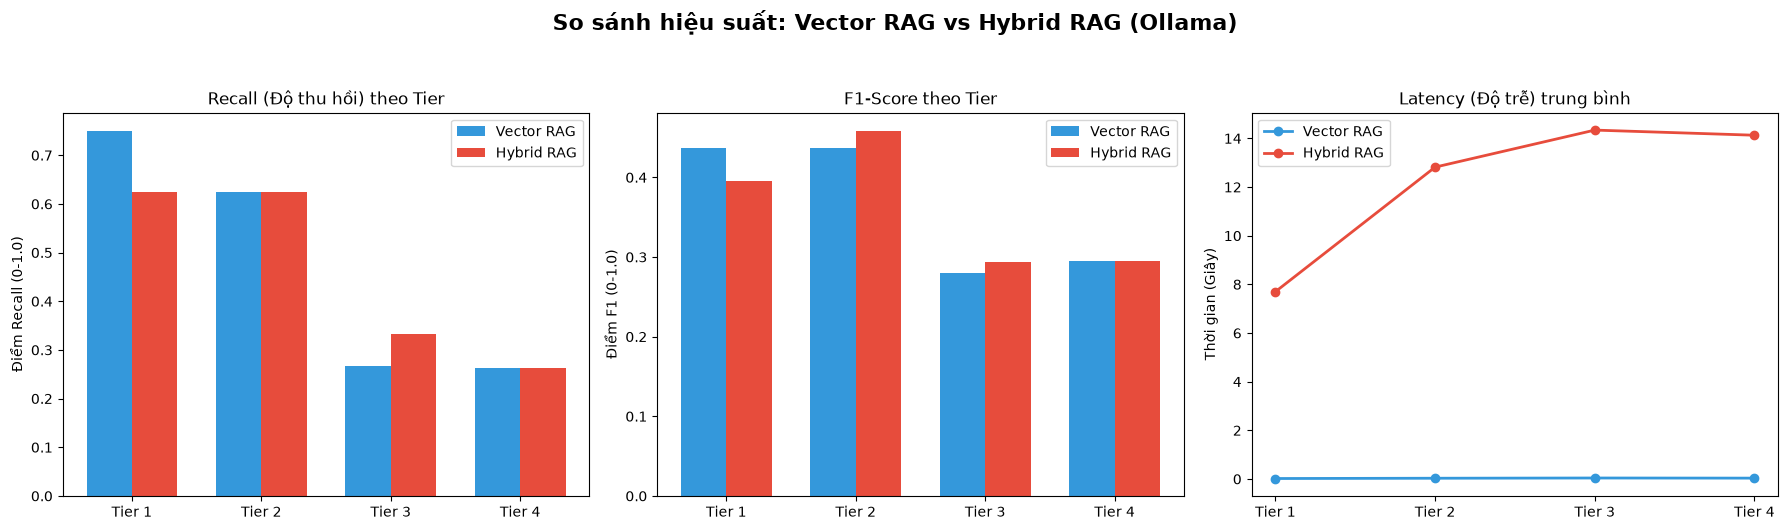

In [25]:
# Cài đặt matplotlib và seaborn nếu chưa có: !pip install matplotlib seaborn
import matplotlib.pyplot as plt
import seaborn as sns

# Gom nhóm dữ liệu theo Tier
tier_summary = df_results.groupby('Tier').agg({
    'B1_Recall': 'mean', 'B2_Recall': 'mean',
    'B1_F1': 'mean', 'B2_F1': 'mean',
    'B1_Latency': 'mean', 'B2_Latency': 'mean'
}).reset_index()

# Thiết lập biểu đồ
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('So sánh hiệu suất: Vector RAG vs Hybrid RAG (Ollama)', fontsize=16, fontweight='bold', y=1.05)

x = np.arange(len(tier_summary['Tier']))
width = 0.35

# 1. Biểu đồ Recall (Khả năng không bỏ sót tài liệu)
axes[0].bar(x - width/2, tier_summary['B1_Recall'], width, label='Vector RAG', color='#3498db')
axes[0].bar(x + width/2, tier_summary['B2_Recall'], width, label='Hybrid RAG', color='#e74c3c')
axes[0].set_title('Recall (Độ thu hồi) theo Tier')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Tier 1', 'Tier 2', 'Tier 3', 'Tier 4'])
axes[0].set_ylabel('Điểm Recall (0-1.0)')
axes[0].legend()

# 2. Biểu đồ F1-Score (Độ chính xác tổng hợp)
axes[1].bar(x - width/2, tier_summary['B1_F1'], width, label='Vector RAG', color='#3498db')
axes[1].bar(x + width/2, tier_summary['B2_F1'], width, label='Hybrid RAG', color='#e74c3c')
axes[1].set_title('F1-Score theo Tier')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Tier 1', 'Tier 2', 'Tier 3', 'Tier 4'])
axes[1].set_ylabel('Điểm F1 (0-1.0)')
axes[1].legend()

# 3. Biểu đồ Latency (Độ trễ)
axes[2].plot(tier_summary['Tier'], tier_summary['B1_Latency'], marker='o', label='Vector RAG', color='#3498db', linewidth=2)
axes[2].plot(tier_summary['Tier'], tier_summary['B2_Latency'], marker='o', label='Hybrid RAG', color='#e74c3c', linewidth=2)
axes[2].set_title('Latency (Độ trễ) trung bình')
axes[2].set_xticks([1, 2, 3, 4])
axes[2].set_xticklabels(['Tier 1', 'Tier 2', 'Tier 3', 'Tier 4'])
axes[2].set_ylabel('Thời gian (Giây)')
axes[2].legend()

plt.tight_layout()
plt.show()